In [166]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer

from transformers import AutoModel, AutoTokenizer

model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 5009.08it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=Tru

In [157]:
from transformers import AutoModel, AutoTokenizer

model_name = "bert-large-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:00<00:00, 4638.22it/s]
[transformers] BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [171]:
#!/usr/bin/env python
# coding: utf-8

import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# Load GPT-2
# ============================================================

model_name = "gpt2-medium"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 292/292 [00:00<00:00, 5310.14it/s]


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [204]:
# ============================================================
# Attention entropy / effective tokens / score scale
# Per layer / head / query position
# No causal mask
# ============================================================

def analyze_attention(outputs):

    entropy = []
    neff = []
    pmax = []
    sigma = []

    for layer_attn in outputs.attentions:

        # (heads, query, key)
        A = layer_attn[0]

        layer_entropy = []
        layer_neff = []
        layer_pmax = []
        layer_sigma = []


        for h in range(A.shape[0]):

            head_entropy = []
            head_neff = []
            head_pmax = []
            head_sigma = []


            for q in range(A.shape[1]):

                # full attention distribution
                probs = A[h, q, :]


                # -----------------------------
                # Entropy
                # -----------------------------
                H = -(
                    probs *
                    torch.log(probs + 1e-12)
                ).sum()


                # -----------------------------
                # Effective number of tokens
                # -----------------------------
                effective = 1 / (
                    probs**2
                ).sum()


                # -----------------------------
                # Recover logits up to constant
                # -----------------------------
                logits = torch.log(
                    probs + 1e-12
                )

                score_std = logits.std(
                    unbiased=False
                )


                head_entropy.append(
                    H.item()
                )

                head_neff.append(
                    effective.item()
                )

                head_pmax.append(
                    probs.max().item()
                )

                head_sigma.append(
                    score_std.item()
                )


            layer_entropy.append(
                head_entropy
            )

            layer_neff.append(
                head_neff
            )

            layer_pmax.append(
                head_pmax
            )

            layer_sigma.append(
                head_sigma
            )


        entropy.append(layer_entropy)
        neff.append(layer_neff)
        pmax.append(layer_pmax)
        sigma.append(layer_sigma)


    return (
        torch.tensor(entropy),
        torch.tensor(neff),
        torch.tensor(pmax),
        torch.tensor(sigma)
    )

In [207]:
Lambda_mean = torch.nanmean(Lambda, dim=2)

plt.figure(figsize=(10,6))

plt.imshow(
    Lambda_mean.numpy(),
    aspect="auto",
    origin="lower"
)

plt.colorbar(label=r"$\Lambda$")

plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Mean Lambda per Layer and Head")

plt.show()

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

In [205]:
entropy, neff, pmax, sigma = analyze_attention(outputs)

print("Entropy shape:", entropy.shape)
print("Sigma shape:", sigma.shape)

Entropy shape: torch.Size([24, 16, 24])
Sigma shape: torch.Size([24, 16, 24])


TypeError: Invalid shape (24, 16, 24) for image data

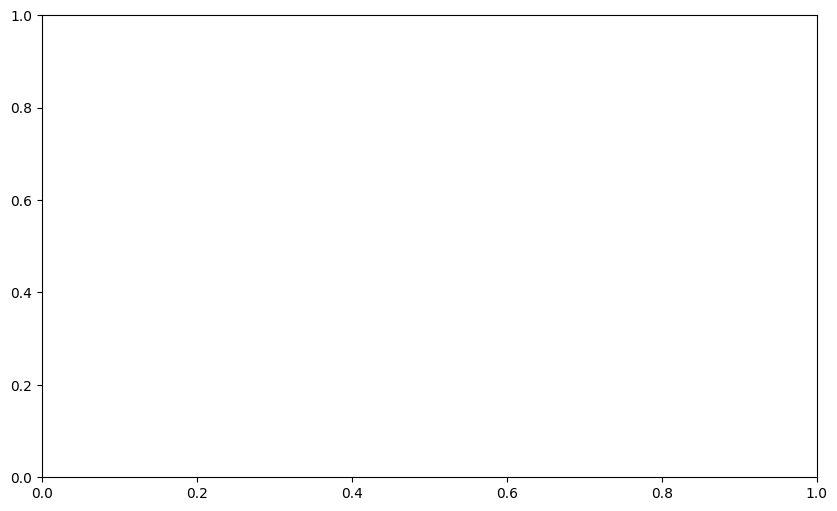

In [206]:
# ============================================================
# Plot entropy
# ============================================================

plt.figure(figsize=(10,6))

plt.imshow(
    entropy.numpy(),
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Entropy")

plt.xlabel("Head")
plt.ylabel("Layer")

plt.title("GPT-2 Attention Entropy")

plt.show()

In [193]:
# ============================================================
# Lambda calculation
#
# Lambda = sup_t log(N(t))/t
#
# Using:
# Delta_j = log(a_max)-log(a_j)
# ============================================================


def lambda_from_attention_head(A, eps=1e-6):

    """
    A:
        (query, key)
    """

    log_A = torch.log(
        A + 1e-12
    )


    lambdas = []


    for q in range(log_A.shape[0]):

        # causal mask
        row = log_A[q, :q+1]


        # energy gaps
        delta = row.max() - row


        delta = delta.detach().cpu().numpy()


        # remove zero gap and tiny scales
        delta = np.sort(
            delta[delta > eps]
        )


        if len(delta) < 2:
            continue


        k = np.arange(
            1,
            len(delta)+1
        )


        values = (
            np.log(k) /
            delta
        )


        lambdas.append(
            np.max(values)
        )


    if len(lambdas) == 0:
        return np.nan


    return np.mean(lambdas)



def compute_lambda_matrix(outputs):

    Lambda = []


    for layer_attn in outputs.attentions:

        # heads, query, key
        A = layer_attn[0]


        layer_lambda = []


        for h in range(A.shape[0]):

            lam = lambda_from_attention_head(
                A[h]
            )

            layer_lambda.append(
                lam
            )


        Lambda.append(
            layer_lambda
        )


    return torch.tensor(Lambda)



Lambda = compute_lambda_matrix(outputs)


print("Lambda shape:", Lambda.shape)

Lambda shape: torch.Size([24, 16])


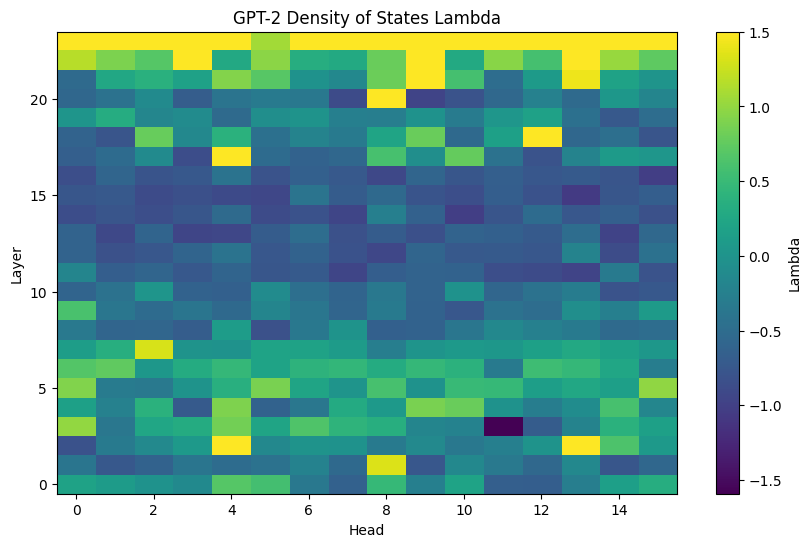

In [180]:
# ============================================================
# Plot Lambda
# ============================================================

plt.figure(figsize=(10,6))

plt.imshow(
    np.log(Lambda.numpy()),
    aspect="auto",
    origin="lower",
    vmax=1.5
)

plt.colorbar(
    label="Lambda"
)

plt.xlabel("Head")
plt.ylabel("Layer")

plt.title(
    "GPT-2 Density of States Lambda"
)

plt.show()

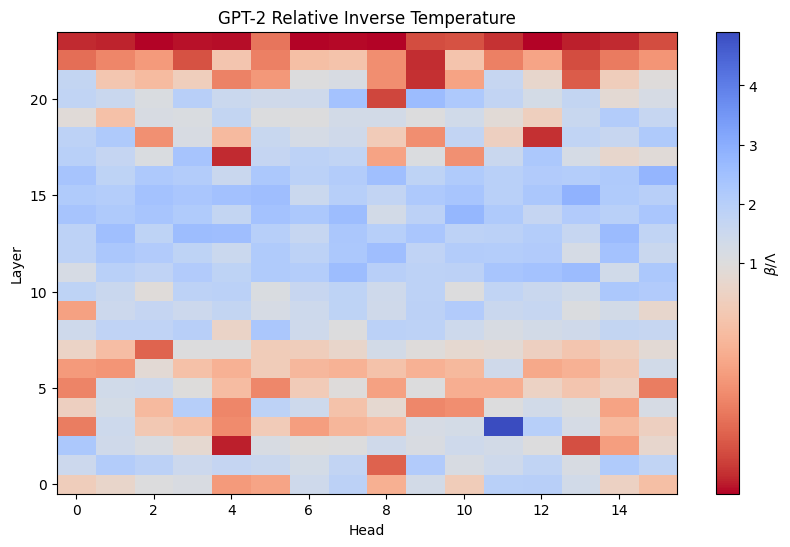

In [181]:
# ============================================================
# Relative temperature
#
# beta = 1 for standard softmax
#
# beta/Lambda = 1/Lambda
# ============================================================


ratio = 1 / Lambda


ratio_np = ratio.numpy()

norm = TwoSlopeNorm(
    vmin=np.nanmin(ratio_np),
    vcenter=1.0,
    vmax=np.nanmax(ratio_np)
)


plt.figure(figsize=(10,6))

plt.imshow(
    ratio.numpy(),
    aspect="auto",
    origin="lower",
    norm=norm,
    cmap="coolwarm_r"
)


plt.colorbar(
    label=r"$\beta/\Lambda$"
)


plt.xlabel("Head")
plt.ylabel("Layer")

plt.title(
    "GPT-2 Relative Inverse Temperature"
)

plt.show()

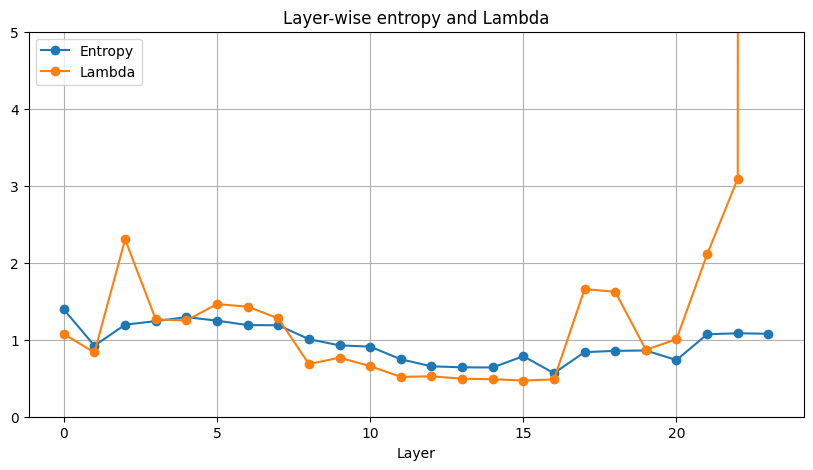

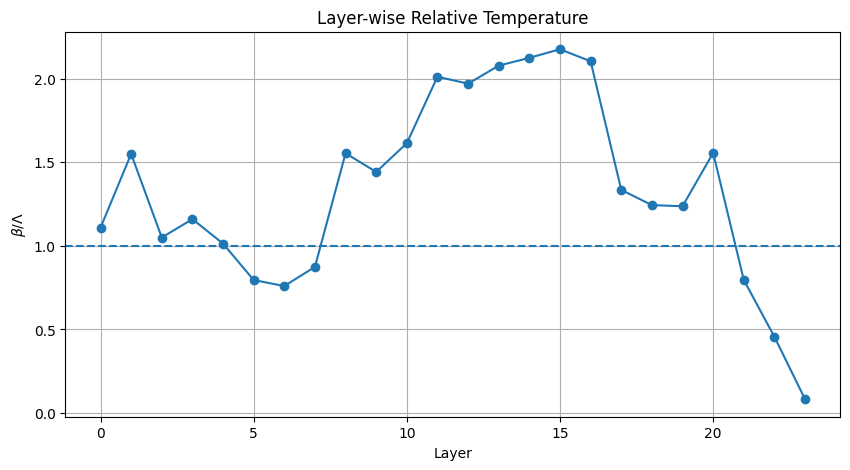

In [190]:
# ============================================================
# Layer averages
# ============================================================

mean_entropy = entropy.mean(dim=1)
mean_lambda = Lambda.mean(dim=1)
mean_ratio = ratio.mean(dim=1)


plt.figure(figsize=(10,5))

plt.plot(
    mean_entropy.numpy(),
    marker="o",
    label="Entropy"
)


plt.plot(
    mean_lambda.numpy(),
    marker="o",
    label="Lambda"
)

plt.ylim([0, 5])


plt.xlabel("Layer")
plt.grid()
plt.legend()
plt.title(
    "Layer-wise entropy and Lambda"
)

plt.show()



plt.figure(figsize=(10,5))

plt.plot(
    mean_ratio.numpy(),
    marker="o"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel("Layer")
plt.ylabel(r"$\beta/\Lambda$")

plt.grid()

plt.title(
    "Layer-wise Relative Temperature"
)

plt.show()

In [191]:
prompts = [

    # ~10 tokens: deterministic
    "The capital of France is",

    # ~20 tokens: repetition / low entropy
    "red blue red blue red blue red blue red blue red blue",

    # ~40 tokens: factual sequence
    "The first five prime numbers are 2, 3, 5, 7, 11. The next prime number is",

    # ~60 tokens: structured completion
    "The planets closest to the Sun are Mercury, Venus, Earth, and Mars. The planets farther away are Jupiter, Saturn, Uranus, and Neptune. The largest planet is",

    # ~80 tokens: semantic association
    "A scientist performs experiments in a laboratory. A historian studies events from the past. A mathematician studies abstract structures. A musician creates melodies. A programmer writes",

    # ~100 tokens: ambiguous reasoning
    "Throughout history, humans have developed different methods for understanding the world around them. Some rely on observation and measurement, while others rely on logic, intuition, or shared cultural knowledge. These different approaches influence how societies make decisions and discover new ideas. One important consequence is",

    # ~120 tokens: long-range dependency
    "Marie was born in Paris and studied chemistry before moving to London. James was born in Toronto and studied physics before moving to Boston. Sarah was born in Paris and studied mathematics before moving to Berlin. Unlike James, Sarah focused primarily on",

    # ~150 tokens: scientific narrative
    "In the early twentieth century, researchers began exploring the strange behavior of matter at extremely small scales. Classical theories that had worked well for everyday objects failed to explain observations involving atoms and particles. Several scientists proposed new mathematical frameworks that challenged existing assumptions. Over time, these ideas became the foundation of modern physics and led to technologies that transformed society. The central concept behind this revolution was",

    # ~170 tokens: high entropy creative
    "The abandoned observatory stood on the edge of a mountain range, untouched for decades after the researchers who built it disappeared. Inside, instruments covered in dust remained connected to computers that had never been switched off. When a young engineer finally entered the building, they discovered that the machines had continued recording unusual patterns in the night sky. The data contained references to locations, numbers, and symbols that appeared unrelated at first. After months of analysis, the engineer realized that the patterns represented",

    # ~200 tokens: complex multi-domain
    "Human civilization has been shaped by the interaction between technology, economics, geography, and culture. The development of agriculture allowed populations to grow, while improvements in transportation enabled the exchange of ideas across distant regions. Scientific discoveries often emerged from unexpected connections between different fields, such as mathematics, astronomy, engineering, and biology. In the modern era, computers and artificial intelligence have accelerated this process by allowing humans to analyze enormous amounts of information and discover patterns that were previously impossible to observe. However, these advances also introduce questions about responsibility, adaptation, and the future relationship between humans and machines. One of the most important challenges facing society is"
]

In [134]:
prompts = [
    """
In the early 1900s, a mathematician investigating the foundations of geometry introduced a surprising idea that challenged assumptions held for centuries. At first, the proposal was considered an unusual abstraction with little connection to practical problems. However, as advances in physics and computing revealed new ways to represent space, motion, and information, researchers began to recognize the importance of the mathematician's work. The original insight was that the structures used to describe the world did not necessarily have to follow familiar rules, and that alternative systems could provide powerful tools for understanding complex phenomena. This shift in perspective eventually influenced areas ranging from theoretical physics to modern computer science, demonstrating how ideas that appear purely theoretical can later become essential frameworks for solving real-world problems.    """
]

<>:61: SyntaxWarning: invalid escape sequence '\/'
<>:61: SyntaxWarning: invalid escape sequence '\/'
/tmp/ipykernel_23561/3025052835.py:61: SyntaxWarning: invalid escape sequence '\/'
  plt.ylabel("Normalized Entropy $H$ \/ log(n)")


Running prompt 1/10
Layers: 24
Attention shape: torch.Size([1, 16, 5, 5])


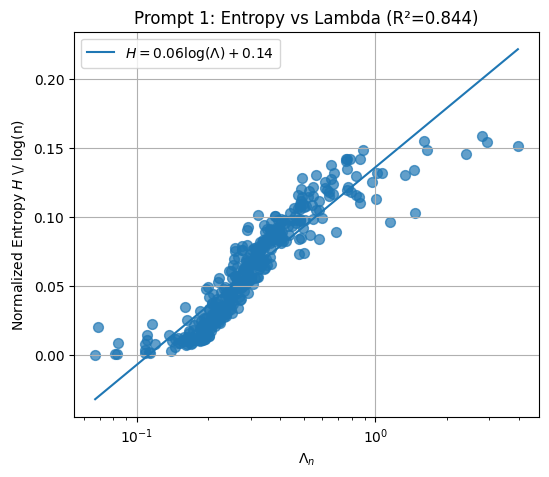

Running prompt 2/10
Layers: 24
Attention shape: torch.Size([1, 16, 12, 12])


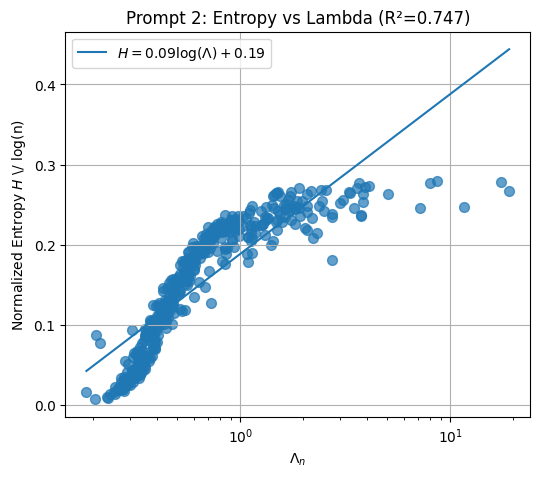

Running prompt 3/10
Layers: 24
Attention shape: torch.Size([1, 16, 21, 21])


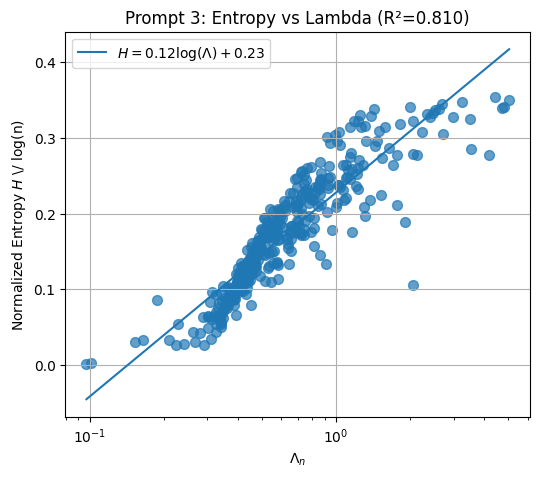

Running prompt 4/10
Layers: 24
Attention shape: torch.Size([1, 16, 35, 35])


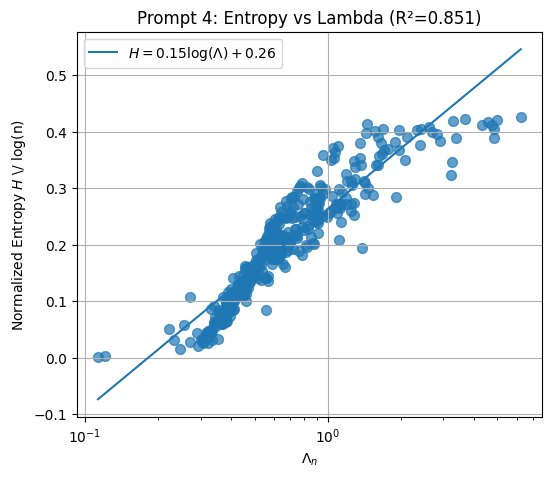

Running prompt 5/10
Layers: 24
Attention shape: torch.Size([1, 16, 30, 30])


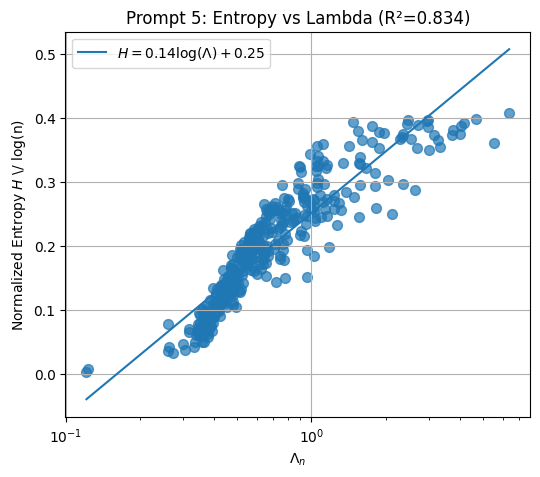

Running prompt 6/10
Layers: 24
Attention shape: torch.Size([1, 16, 52, 52])


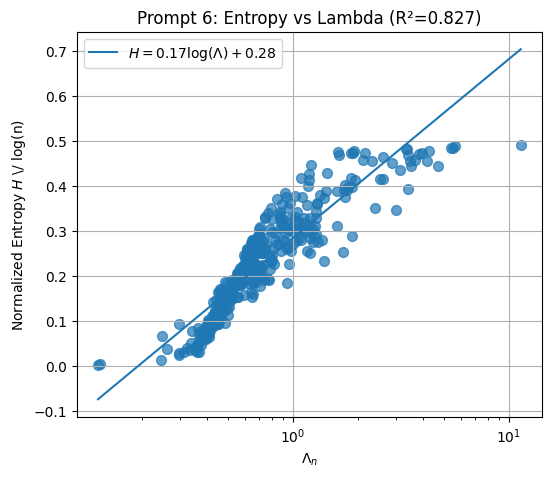

Running prompt 7/10
Layers: 24
Attention shape: torch.Size([1, 16, 46, 46])


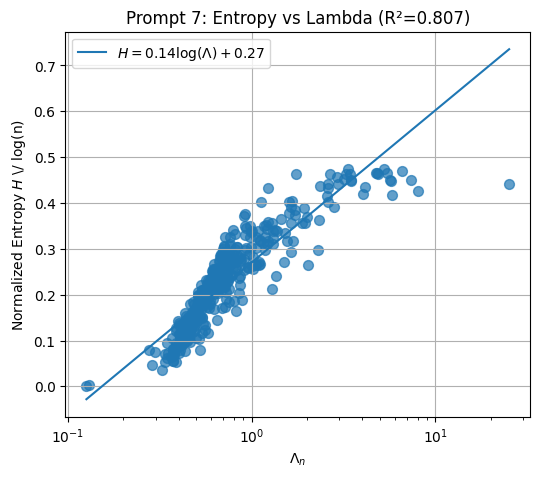

Running prompt 8/10
Layers: 24
Attention shape: torch.Size([1, 16, 74, 74])


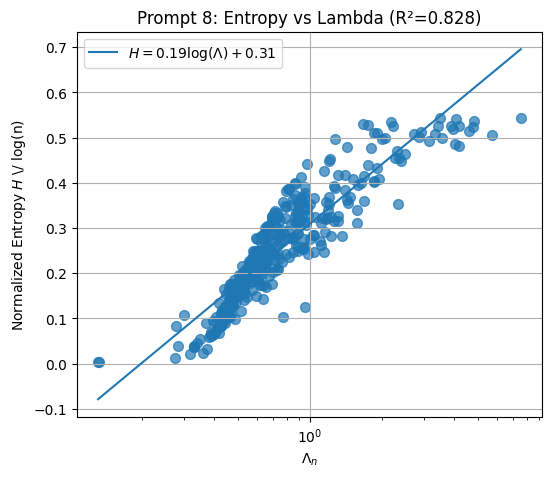

Running prompt 9/10
Layers: 24
Attention shape: torch.Size([1, 16, 94, 94])


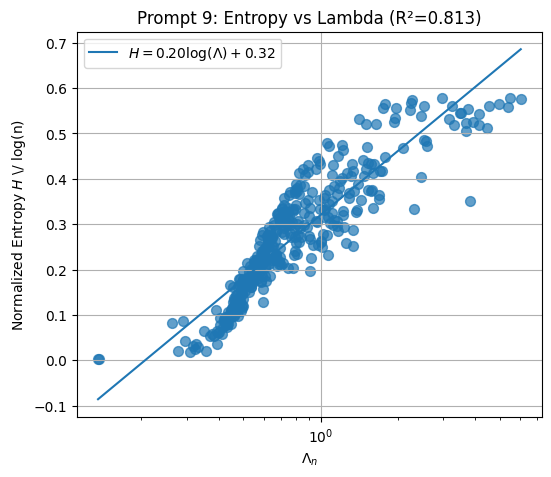

Running prompt 10/10
Layers: 24
Attention shape: torch.Size([1, 16, 124, 124])


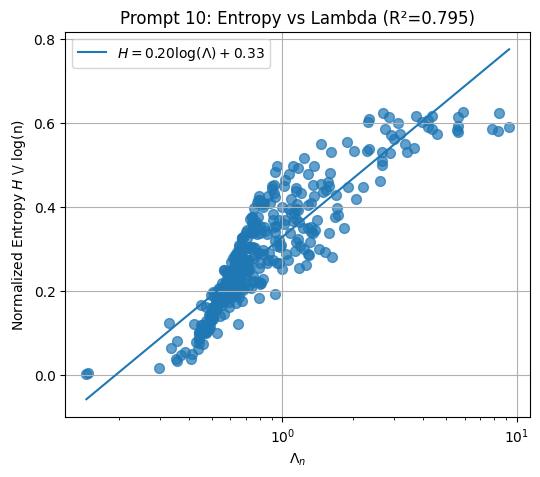


Results:
Prompt 1: slope=0.062, intercept=0.136, R²=0.844
Prompt 2: slope=0.087, intercept=0.189, R²=0.747
Prompt 3: slope=0.117, intercept=0.228, R²=0.810
Prompt 4: slope=0.154, intercept=0.263, R²=0.851
Prompt 5: slope=0.138, intercept=0.252, R²=0.834
Prompt 6: slope=0.173, intercept=0.285, R²=0.827
Prompt 7: slope=0.144, intercept=0.270, R²=0.807
Prompt 8: slope=0.191, intercept=0.309, R²=0.828
Prompt 9: slope=0.203, intercept=0.320, R²=0.813
Prompt 10: slope=0.201, intercept=0.328, R²=0.795


In [203]:
results = []

xs = None

for i, prompt in enumerate(prompts):

    print(f"Running prompt {i+1}/{len(prompts)}")

    data, Lambda = load_prompt(prompt)

    entropy, neff, pmax, sigma = data
    xs = data

    # flatten heads/layers
    H = entropy.flatten().numpy()
    H = H / np.log(H.shape[-1])
    L = Lambda.flatten().numpy()

    # remove invalid values
    mask = np.isfinite(H) & np.isfinite(L) & (L > 0)

    H = H[mask]
    L = L[mask]

    # log fit: H = a log(Lambda) + b
    x = np.log(L)

    a, b = np.polyfit(x, H, 1)

    pred = a*x + b

    r2 = 1 - np.sum((H-pred)**2) / np.sum((H-H.mean())**2)

    results.append({
        "prompt": i,
        "slope": a,
        "intercept": b,
        "r2": r2
    })

    # plot each prompt
    plt.figure(figsize=(6,5))

    plt.scatter(
        L,
        H,
        s=50,
        alpha=0.7
    )

    L_fit = np.linspace(L.min(), L.max(), 200)

    plt.plot(
        L_fit,
        a*np.log(L_fit)+b,
        label=fr"$H={a:.2f}\log(\Lambda)+{b:.2f}$"
    )

    plt.xscale("log")
    plt.xlabel(r"$\Lambda_n$")
    plt.ylabel("Normalized Entropy $H$ \/ log(n)")
    plt.title(f"Prompt {i+1}: Entropy vs Lambda (R²={r2:.3f})")
    plt.grid()
    plt.legend()

    plt.show()


print("\nResults:")
for r in results:
    print(
        f"Prompt {r['prompt']+1}: "
        f"slope={r['slope']:.3f}, "
        f"intercept={r['intercept']:.3f}, "
        f"R²={r['r2']:.3f}"
    )

Running prompt 1/10
Layers: 12
Attention shape: torch.Size([1, 12, 7, 7])


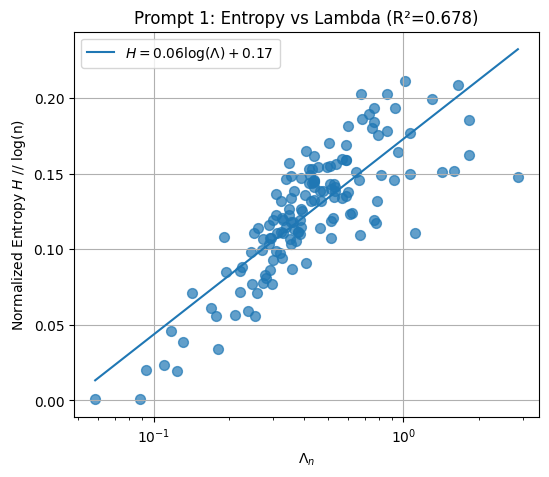

Running prompt 2/10
Layers: 12
Attention shape: torch.Size([1, 12, 14, 14])


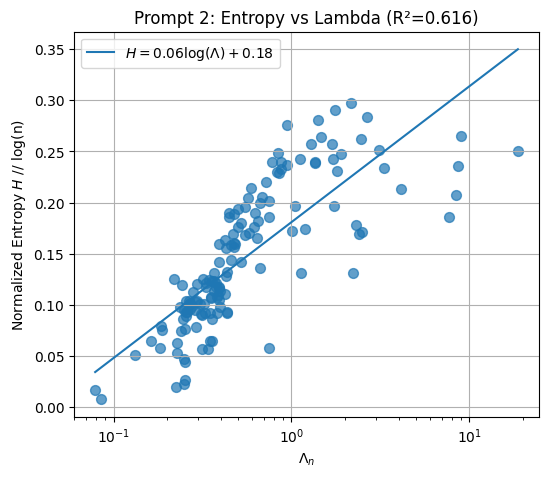

Running prompt 3/10
Layers: 12
Attention shape: torch.Size([1, 12, 23, 23])


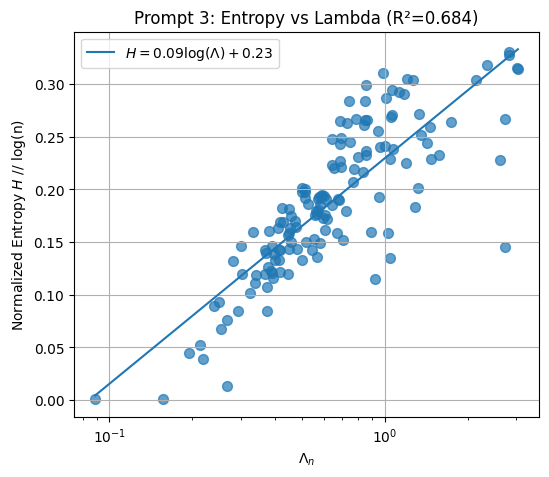

Running prompt 4/10
Layers: 12
Attention shape: torch.Size([1, 12, 37, 37])


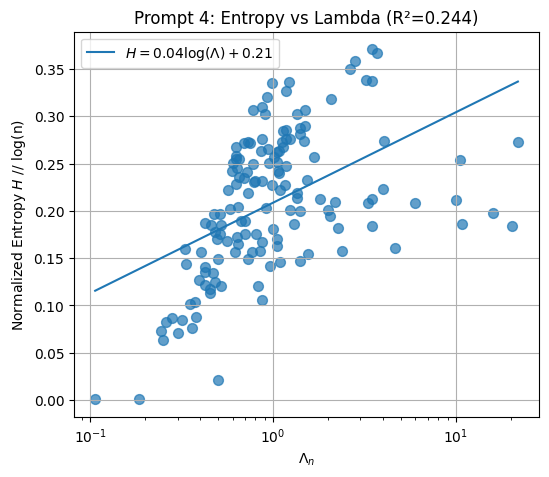

Running prompt 5/10
Layers: 12
Attention shape: torch.Size([1, 12, 32, 32])


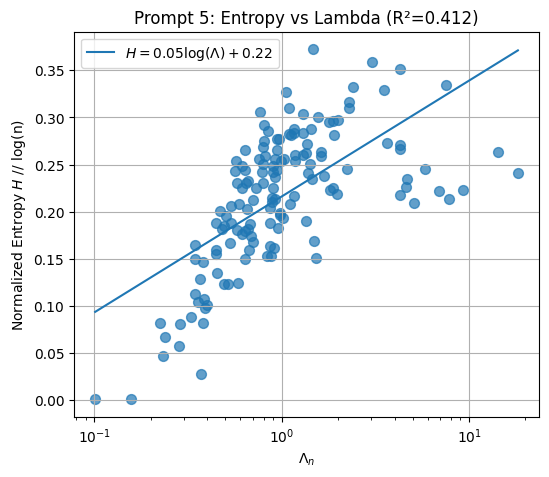

Running prompt 6/10
Layers: 12
Attention shape: torch.Size([1, 12, 54, 54])


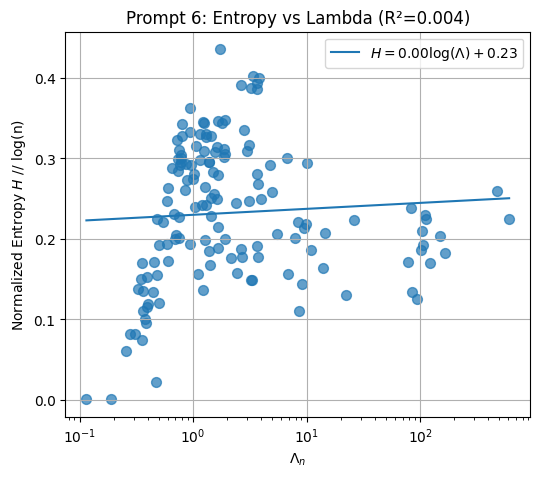

Running prompt 7/10
Layers: 12
Attention shape: torch.Size([1, 12, 48, 48])


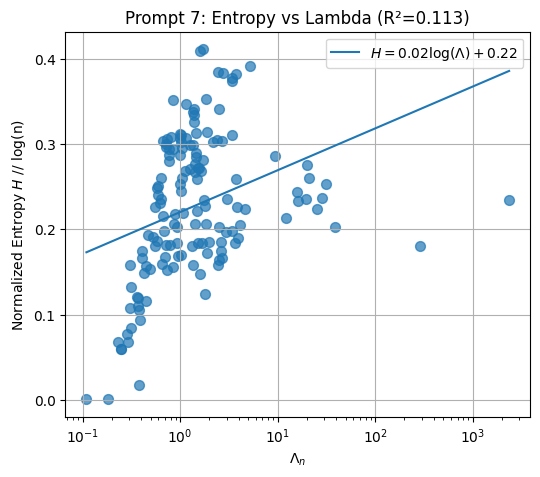

Running prompt 8/10
Layers: 12
Attention shape: torch.Size([1, 12, 76, 76])


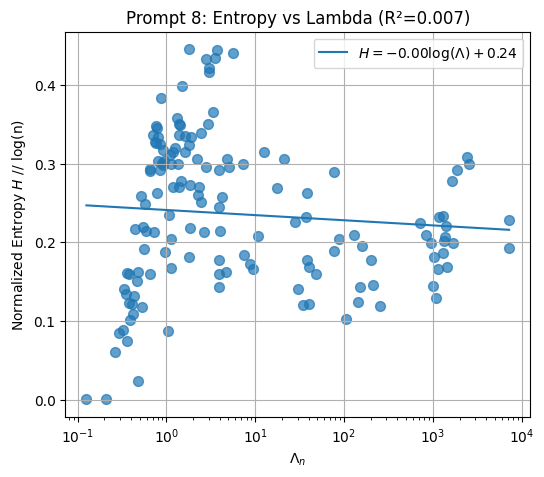

Running prompt 9/10
Layers: 12
Attention shape: torch.Size([1, 12, 96, 96])


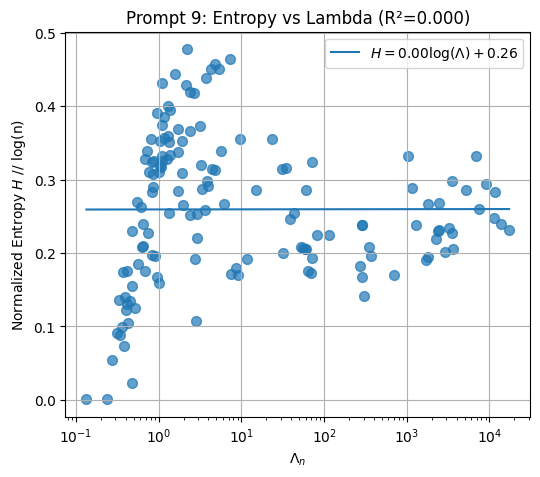

Running prompt 10/10
Layers: 12
Attention shape: torch.Size([1, 12, 126, 126])


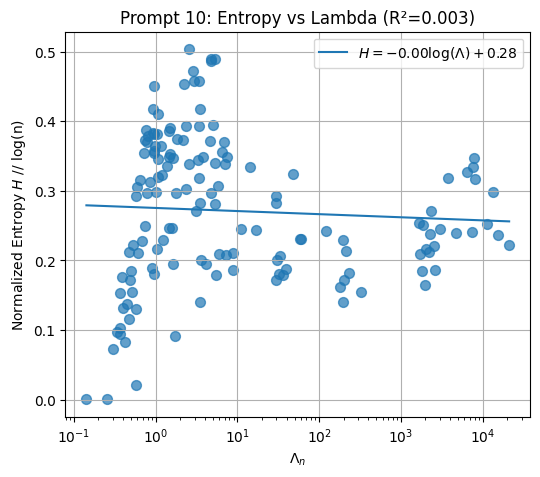


Results:
Prompt 1: slope=0.056, intercept=0.173, R²=0.678
Prompt 2: slope=0.058, intercept=0.181, R²=0.616
Prompt 3: slope=0.093, intercept=0.230, R²=0.684
Prompt 4: slope=0.042, intercept=0.209, R²=0.244
Prompt 5: slope=0.053, intercept=0.216, R²=0.412
Prompt 6: slope=0.003, intercept=0.230, R²=0.004
Prompt 7: slope=0.021, intercept=0.220, R²=0.113
Prompt 8: slope=-0.003, intercept=0.241, R²=0.007
Prompt 9: slope=0.000, intercept=0.259, R²=0.000
Prompt 10: slope=-0.002, intercept=0.275, R²=0.003


In [168]:
results = []

xs = None

for i, prompt in enumerate(prompts):

    print(f"Running prompt {i+1}/{len(prompts)}")

    data, Lambda = load_prompt(prompt)

    entropy, neff, pmax, sigma = data
    xs = data

    # flatten heads/layers
    H = entropy.flatten().numpy()
    H = H / np.log(H.shape[-1])
    L = Lambda.flatten().numpy()

    # remove invalid values
    mask = np.isfinite(H) & np.isfinite(L) & (L > 0)

    H = H[mask]
    L = L[mask]

    # log fit: H = a log(Lambda) + b
    x = np.log(L)

    a, b = np.polyfit(x, H, 1)

    pred = a*x + b

    r2 = 1 - np.sum((H-pred)**2) / np.sum((H-H.mean())**2)

    results.append({
        "prompt": i,
        "slope": a,
        "intercept": b,
        "r2": r2
    })

    # plot each prompt
    plt.figure(figsize=(6,5))

    plt.scatter(
        L,
        H,
        s=50,
        alpha=0.7
    )

    L_fit = np.linspace(L.min(), L.max(), 200)

    plt.plot(
        L_fit,
        a*np.log(L_fit)+b,
        label=fr"$H={a:.2f}\log(\Lambda)+{b:.2f}$"
    )

    plt.xscale("log")
    plt.xlabel(r"$\Lambda_n$")
    plt.ylabel("Normalized Entropy $H$ // log(n)")
    plt.title(f"Prompt {i+1}: Entropy vs Lambda (R²={r2:.3f})")
    plt.grid()
    plt.legend()

    plt.show()


print("\nResults:")
for r in results:
    print(
        f"Prompt {r['prompt']+1}: "
        f"slope={r['slope']:.3f}, "
        f"intercept={r['intercept']:.3f}, "
        f"R²={r['r2']:.3f}"
    )

Processing prompt 1/10
Layers: 12
Attention shape: torch.Size([1, 12, 7, 7])
Processing prompt 2/10
Layers: 12
Attention shape: torch.Size([1, 12, 14, 14])
Processing prompt 3/10
Layers: 12
Attention shape: torch.Size([1, 12, 23, 23])
Processing prompt 4/10
Layers: 12
Attention shape: torch.Size([1, 12, 37, 37])
Processing prompt 5/10
Layers: 12
Attention shape: torch.Size([1, 12, 32, 32])
Processing prompt 6/10
Layers: 12
Attention shape: torch.Size([1, 12, 54, 54])
Processing prompt 7/10
Layers: 12
Attention shape: torch.Size([1, 12, 48, 48])
Processing prompt 8/10
Layers: 12
Attention shape: torch.Size([1, 12, 76, 76])
Processing prompt 9/10
Layers: 12
Attention shape: torch.Size([1, 12, 96, 96])
Processing prompt 10/10
Layers: 12
Attention shape: torch.Size([1, 12, 126, 126])
Combined fit: H = 0.013 log(Lambda) + 0.204
R² = 0.0946


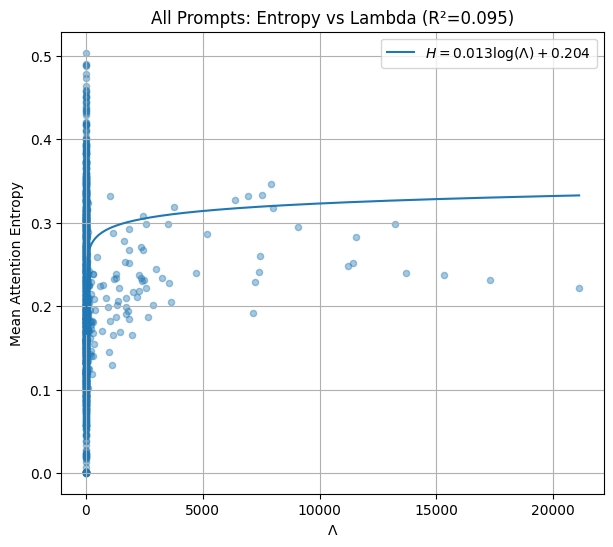

In [169]:
import numpy as np
import matplotlib.pyplot as plt

all_x = []
all_y = []

for i, prompt in enumerate(prompts):

    print(f"Processing prompt {i+1}/{len(prompts)}")

    data, Lambda = load_prompt(prompt)

    entropy, neff, pmax, sigma = data

    # flatten all layers/heads
    x = Lambda.flatten().numpy()
    y = entropy.flatten().numpy()
    y = y / np.log(y.shape[-1])


    # remove invalid values
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)

    x = x[mask]
    y = y[mask]

    all_x.extend(x)
    all_y.extend(y)


# combined dataset
x = np.array(all_x)
y = np.array(all_y)


# log fit
log_x = np.log(x)

a, b = np.polyfit(log_x, y, 1)

y_pred = a * log_x + b

# R²
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res / ss_tot


print(
    f"Combined fit: "
    f"H = {a:.3f} log(Lambda) + {b:.3f}"
)
print(f"R² = {r2:.4f}")


# Plot
plt.figure(figsize=(7,6))

plt.scatter(
    x,
    y,
    s=20,
    alpha=0.4
)

x_fit = np.linspace(x.min(), x.max(), 300)

plt.plot(
    x_fit,
    a*np.log(x_fit)+b,
    label=fr"$H={a:.3f}\log(\Lambda)+{b:.3f}$"
)

plt.xlabel(r"$\Lambda$")
plt.ylabel("Mean Attention Entropy")
plt.title(
    f"All Prompts: Entropy vs Lambda (R²={r2:.3f})"
)

plt.grid(True)
plt.legend()

plt.show()

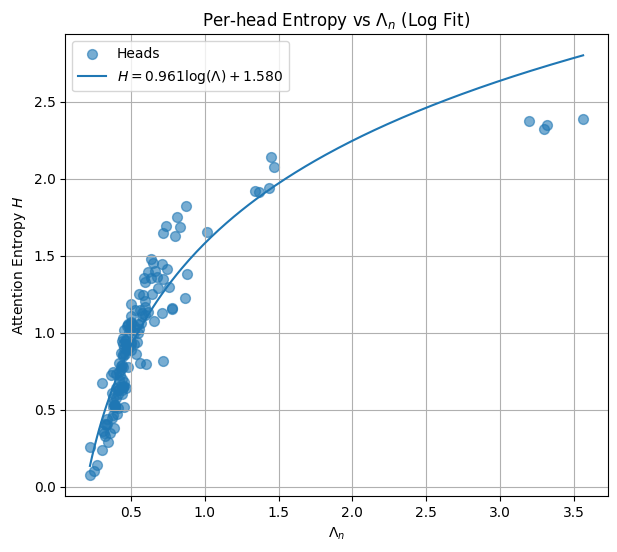

R² = 0.8655
slope = 0.9611


In [114]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten per-head values
x = Lambda.flatten().numpy()
y = entropy.flatten().numpy()

# Remove invalid values
mask = np.isfinite(x) & np.isfinite(y) & (x > 0)

x = x[mask]
y = y[mask]

# Log transform
log_x = np.log(x)

# Fit H = a log(Lambda) + b
a, b = np.polyfit(log_x, y, 1)

# Curve
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = a * np.log(x_fit) + b

plt.figure(figsize=(7,6))

plt.scatter(
    x,
    y,
    s=50,
    alpha=0.6,
    label="Heads"
)

plt.plot(
    x_fit,
    y_fit,
    label=fr"$H={a:.3f}\log(\Lambda)+{b:.3f}$"
)

plt.xlabel(r"$\Lambda_n$")
plt.ylabel("Attention Entropy $H$")
plt.title(r"Per-head Entropy vs $\Lambda_n$ (Log Fit)")
plt.grid()
plt.legend()

plt.show()

# R^2
y_pred = a*np.log(x) + b

ss_res = np.sum((y-y_pred)**2)
ss_tot = np.sum((y-y.mean())**2)

r2 = 1 - ss_res/ss_tot

print(f"R² = {r2:.4f}")
print(f"slope = {a:.4f}")

Running prompt 1/10
Layers: 24
Attention shape: torch.Size([1, 16, 5, 5])


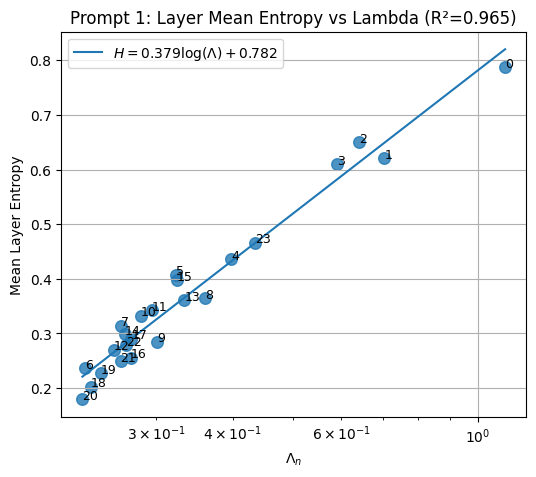

Running prompt 2/10
Layers: 24
Attention shape: torch.Size([1, 16, 12, 12])


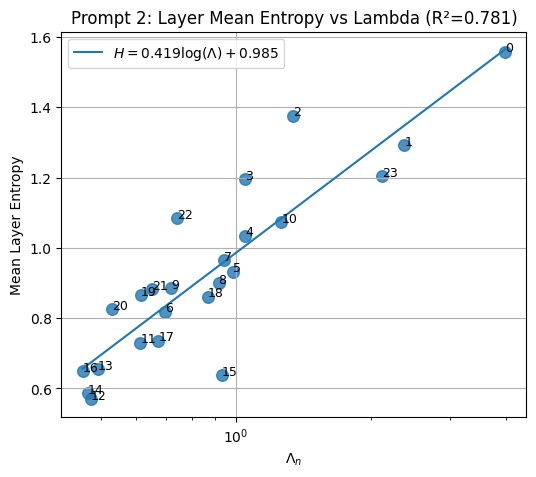

Running prompt 3/10
Layers: 24
Attention shape: torch.Size([1, 16, 21, 21])


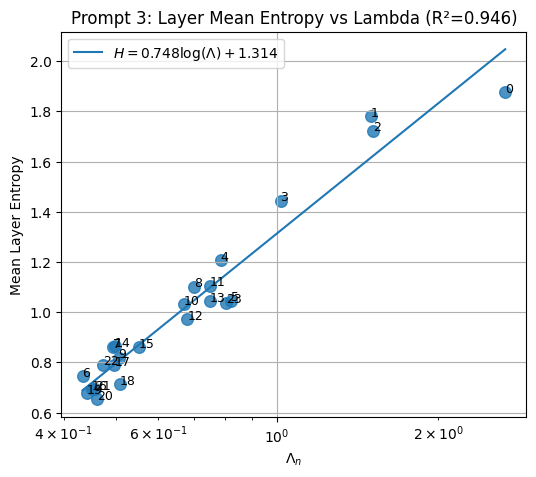

Running prompt 4/10
Layers: 24
Attention shape: torch.Size([1, 16, 35, 35])


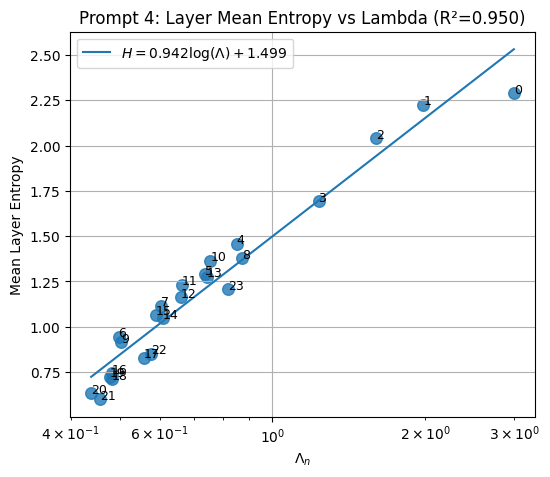

Running prompt 5/10
Layers: 24
Attention shape: torch.Size([1, 16, 30, 30])


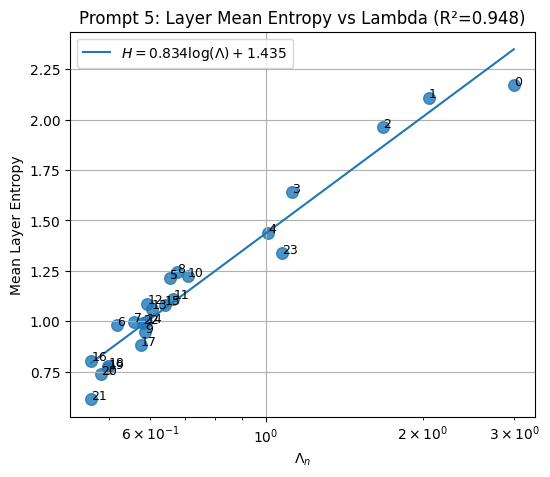

Running prompt 6/10
Layers: 24
Attention shape: torch.Size([1, 16, 52, 52])


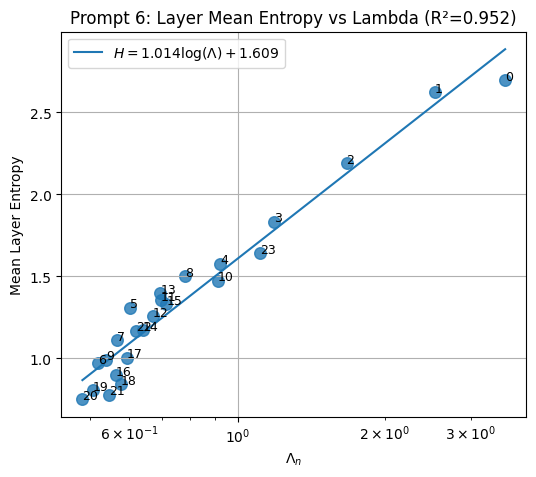

Running prompt 7/10
Layers: 24
Attention shape: torch.Size([1, 16, 46, 46])


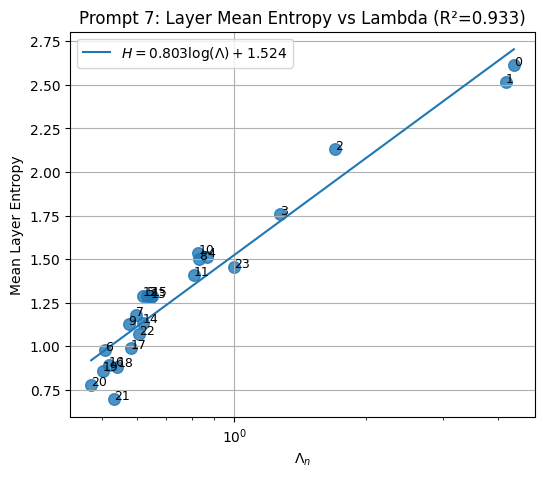

Running prompt 8/10
Layers: 24
Attention shape: torch.Size([1, 16, 74, 74])


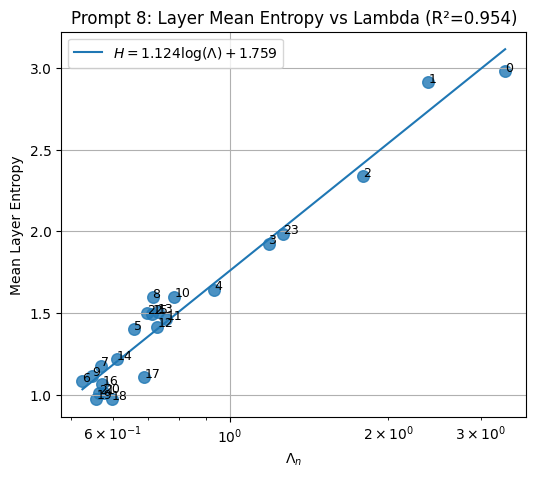

Running prompt 9/10
Layers: 24
Attention shape: torch.Size([1, 16, 94, 94])


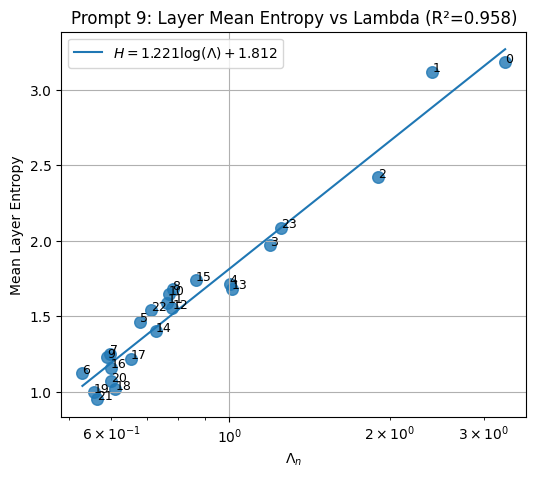

Running prompt 10/10
Layers: 24
Attention shape: torch.Size([1, 16, 124, 124])


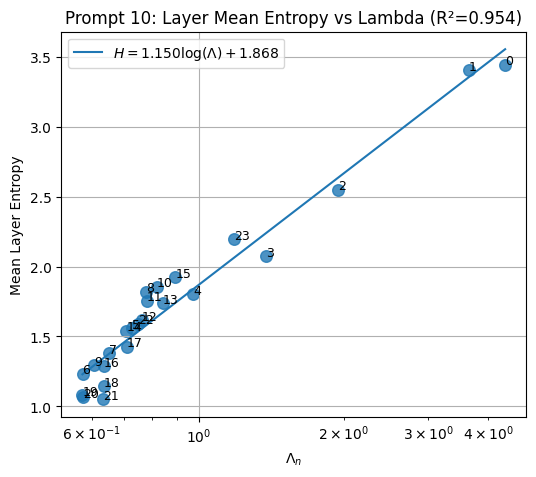


Per-prompt results:
Prompt 1: slope=0.379, intercept=0.782, R²=0.965
Prompt 2: slope=0.419, intercept=0.985, R²=0.781
Prompt 3: slope=0.748, intercept=1.314, R²=0.946
Prompt 4: slope=0.942, intercept=1.499, R²=0.950
Prompt 5: slope=0.834, intercept=1.435, R²=0.948
Prompt 6: slope=1.014, intercept=1.609, R²=0.952
Prompt 7: slope=0.803, intercept=1.524, R²=0.933
Prompt 8: slope=1.124, intercept=1.759, R²=0.954
Prompt 9: slope=1.221, intercept=1.812, R²=0.958
Prompt 10: slope=1.150, intercept=1.868, R²=0.954

Combined layer-level fit:
H = 0.938 log(Lambda) + 1.527
R² = 0.784


In [172]:
results = []

all_H = []
all_L = []

for i, prompt in enumerate(prompts):

    print(f"Running prompt {i+1}/{len(prompts)}")

    data, Lambda = load_prompt(prompt)

    entropy, neff, pmax, sigma = data

    # mean over heads -> one value per layer
    H = entropy.mean(dim=1).numpy()
    L = Lambda.mean(dim=1).numpy()

    # remove invalid values
    mask = np.isfinite(H) & np.isfinite(L) & (L > 0)

    H = H[mask]
    L = L[mask]

    all_H.extend(H)
    all_L.extend(L)

    # fit per prompt
    x = np.log(L)

    a, b = np.polyfit(x, H, 1)

    pred = a*x + b

    r2 = 1 - np.sum((H-pred)**2) / np.sum((H-H.mean())**2)

    results.append({
        "prompt": i,
        "slope": a,
        "intercept": b,
        "r2": r2
    })

    # plot
    plt.figure(figsize=(6,5))

    plt.scatter(
        L,
        H,
        s=70,
        alpha=0.8
    )

    L_fit = np.linspace(L.min(), L.max(), 200)

    plt.plot(
        L_fit,
        a*np.log(L_fit)+b,
        label=fr"$H={a:.3f}\log(\Lambda)+{b:.3f}$"
    )

    # layer labels
    for layer, (lx, ly) in enumerate(zip(L,H)):
        plt.text(lx, ly, str(layer), fontsize=9)

    plt.xscale("log")
    plt.xlabel(r"$\Lambda_n$")
    plt.ylabel("Mean Layer Entropy")
    plt.title(f"Prompt {i+1}: Layer Mean Entropy vs Lambda (R²={r2:.3f})")
    plt.grid()
    plt.legend()

    plt.show()


print("\nPer-prompt results:")
for r in results:
    print(
        f"Prompt {r['prompt']+1}: "
        f"slope={r['slope']:.3f}, "
        f"intercept={r['intercept']:.3f}, "
        f"R²={r['r2']:.3f}"
    )


# Combined per-layer fit
H = np.array(all_H)
L = np.array(all_L)

x = np.log(L)

a, b = np.polyfit(x, H, 1)

pred = a*x+b

r2 = 1 - np.sum((H-pred)**2) / np.sum((H-H.mean())**2)

print("\nCombined layer-level fit:")
print(f"H = {a:.3f} log(Lambda) + {b:.3f}")
print(f"R² = {r2:.3f}")

In [194]:
def analyze_attention_per_position(outputs):

    entropy = []
    Lambda = []

    for layer_attn in outputs.attentions:

        # (heads, query, key)
        A = layer_attn[0]

        layer_entropy = []
        layer_lambda = []

        for h in range(A.shape[0]):

            head_entropy = []
            head_lambda = []

            for q in range(A.shape[1]):

                # causal attention
                probs = A[h, q, :q+1]

                # entropy
                H = -(
                    probs *
                    torch.log(probs + 1e-12)
                ).sum()

                head_entropy.append(
                    H.item()
                )


                # Lambda for this exact query position

                logits = torch.log(
                    probs + 1e-12
                )

                delta = (
                    logits.max() - logits
                )

                delta = delta.detach().cpu().numpy()

                delta = np.sort(
                    delta[delta > 1e-6]
                )

                if len(delta) < 2:
                    head_lambda.append(np.nan)
                    continue

                k = np.arange(
                    1,
                    len(delta)+1
                )

                values = (
                    np.log(k) /
                    delta
                )

                head_lambda.append(
                    np.max(values)
                )


            layer_entropy.append(head_entropy)
            layer_lambda.append(head_lambda)


        entropy.append(layer_entropy)
        Lambda.append(layer_lambda)


    return (
        torch.tensor(entropy),
        torch.tensor(Lambda)
    )

H = 0.2858 log(Lambda) + 1.0565
R² = 0.2258


ValueError: 'c' argument has 9216 elements, which is inconsistent with 'x' and 'y' with size 8448.

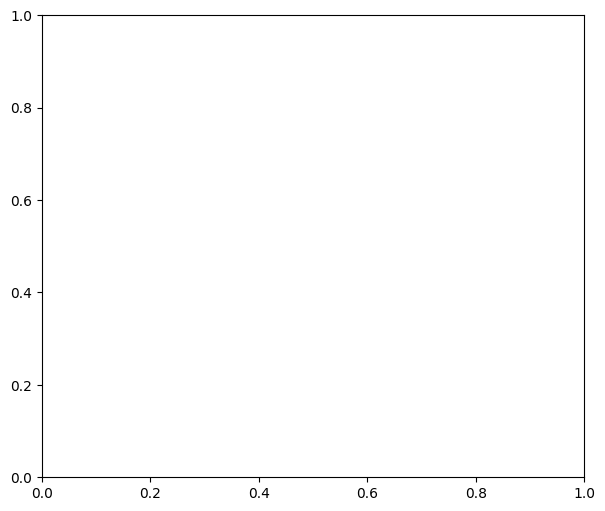

In [200]:
import numpy as np
import matplotlib.pyplot as plt


entropy, Lambda = analyze_attention_per_position(outputs)

num_layers, num_heads, num_queries = entropy.shape

layer_ids = np.repeat(
    np.arange(num_layers),
    num_heads * num_queries
)

# flatten layer/head/query
H = entropy.flatten().numpy()
L = Lambda.flatten().numpy()

layer_ids = np.indices(entropy.shape)[0].flatten()



# remove invalid values
mask = (
    np.isfinite(H)
    &
    np.isfinite(L)
    &
    (L > 0)
)

H = H[mask]
L = L[mask]


# optional: remove tiny context lengths
# (requires returning q indices; skip for now)


# log fit
x = np.log(L)

a, b = np.polyfit(x, H, 1)

pred = a*x + b

r2 = (
    1 -
    np.sum((H-pred)**2) /
    np.sum((H-H.mean())**2)
)


print(
    f"H = {a:.4f} log(Lambda) + {b:.4f}"
)

print(
    f"R² = {r2:.4f}"
)


# plot
plt.figure(figsize=(7,6))


plt.scatter(
    L,
    H,
    c=layer_ids,
    s=15,
    alpha=0.5,
    cmap="viridis"
)

L_fit = np.linspace(
    L.min(),
    L.max(),
    300
)

plt.plot(
    L_fit,
    a*np.log(L_fit)+b,
    linewidth=2,
    label=fr"$H={a:.3f}\log(\Lambda)+{b:.3f}$"
)

plt.xscale("log")

plt.xlabel(r"$\Lambda_q$")
plt.ylabel(r"$H_q$")

plt.title(
    f"Attention Entropy vs Local Landscape Complexity\nR²={r2:.3f}"
)

plt.grid()
plt.legend()

plt.show()

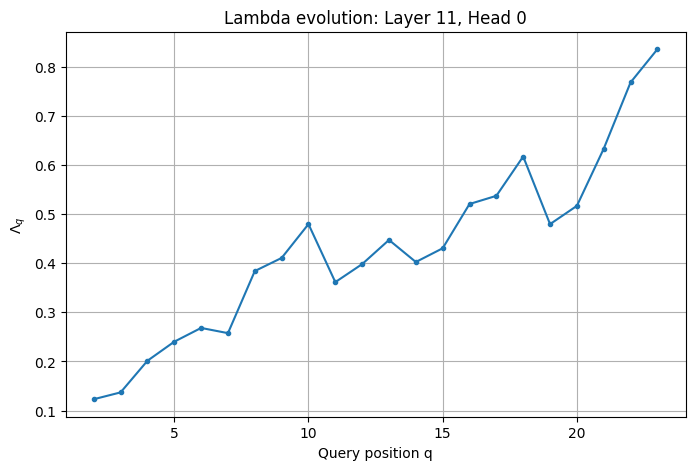

In [201]:
import matplotlib.pyplot as plt
import numpy as np

# choose layer and head
layer = 11
head = 0

# extract Lambda across query positions
lambda_q = Lambda[layer, head].numpy()

# remove invalid values
mask = np.isfinite(lambda_q)

q = np.arange(len(lambda_q))

plt.figure(figsize=(8,5))

plt.plot(
    q[mask],
    lambda_q[mask],
    marker="o",
    markersize=3
)

plt.xlabel("Query position q")
plt.ylabel(r"$\Lambda_q$")
plt.title(
    f"Lambda evolution: Layer {layer}, Head {head}"
)

plt.grid()

plt.show()